**CSI 4106 Introduction to Artificial Intelligence** <br/>
*Assignment 2: Machine Learning*

# Identification

Name: Kanjanokphat Kitisuwanakul <br/>
Student Number: 300170040

Name:  Kien Do <br/>
Student Number: 300163370




## 1. Exploratory Analysis



 Data Exploration

In this assignment, we will utilize the Diabetes Prediction Dataset, accessible via [Diabetes Prediction Dataset](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset/data). To mitigate the complexity associated with Kaggle's login requirement, the dataset has been made available on a public GitHub repository:

- [github.com/turcotte/csi4106-f24/tree/main/assignments-data/a2](https://github.com/turcotte/csi4106-f24/tree/main/assignments-data/a2)

You can access and read the dataset directly from this GitHub repository in your Jupyter notebook.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn import tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict

In [ ]:
url = "https://raw.githubusercontent.com/turcotte/csi4106-f24/refs/heads/main/assignments-data/a2/diabetes_prediction_dataset.csv"
# provide the link to the raw version of dataset. You *need* to provide a link to *your own* github repository. DO NOT use the link that is provided as an example.

df = pd.read_csv(url)

### **1**. **Load the dataset and provide a summary of its structure**:

- Describe the features (columns), their data types, and the target variable.

In [ ]:
# Display the first few rows of the DataFrame
print(df.head())

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


In [ ]:
# Analyze the statistics for this dataset
print(df.describe())

                 age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.320767   
std        22.516840       0.26315       0.194593       6.636783   
min         0.080000       0.00000       0.000000      10.010000   
25%        24.000000       0.00000       0.000000      23.630000   
50%        43.000000       0.00000       0.000000      27.320000   
75%        60.000000       0.00000       0.000000      29.580000   
max        80.000000       1.00000       1.000000      95.690000   

         HbA1c_level  blood_glucose_level       diabetes  
count  100000.000000        100000.000000  100000.000000  
mean        5.527507           138.058060       0.085000  
std         1.070672            40.708136       0.278883  
min         3.500000            80.000000       0.000000  
25%         4.800000           100.000000       0.000000  
50%         5.800000           14

In [ ]:
# Print the features' data types
print(df.dtypes)

gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object


In [ ]:
# Features of the dataset

print("Features:")
print(df[['gender', 'age', 'hypertension', 'heart_disease','smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level'] ])

Features:
       gender   age  hypertension  heart_disease smoking_history    bmi  \
0      Female  80.0             0              1           never  25.19   
1      Female  54.0             0              0         No Info  27.32   
2        Male  28.0             0              0           never  27.32   
3      Female  36.0             0              0         current  23.45   
4        Male  76.0             1              1         current  20.14   
...       ...   ...           ...            ...             ...    ...   
99995  Female  80.0             0              0         No Info  27.32   
99996  Female   2.0             0              0         No Info  17.37   
99997    Male  66.0             0              0          former  27.83   
99998  Female  24.0             0              0           never  35.42   
99999  Female  57.0             0              0         current  22.43   

       HbA1c_level  blood_glucose_level  
0              6.6                  140  
1    

In [ ]:
# Label of the dataset

print(df['diabetes'])

0        0
1        0
2        0
3        0
4        0
        ..
99995    0
99996    0
99997    0
99998    0
99999    0
Name: diabetes, Length: 100000, dtype: int64


In [ ]:
# The label, diabetes is a binary value
# 0 represents absence of diabetes
# 1 represents presence of diabetes

print(df['diabetes'].unique())

[0 1]


### 2. **Feature Distribution Analysis**:

- Examine the distribution of each feature using appropriate visualizations such as histograms and boxplots. Discuss insights gained, including the presence of outliers.

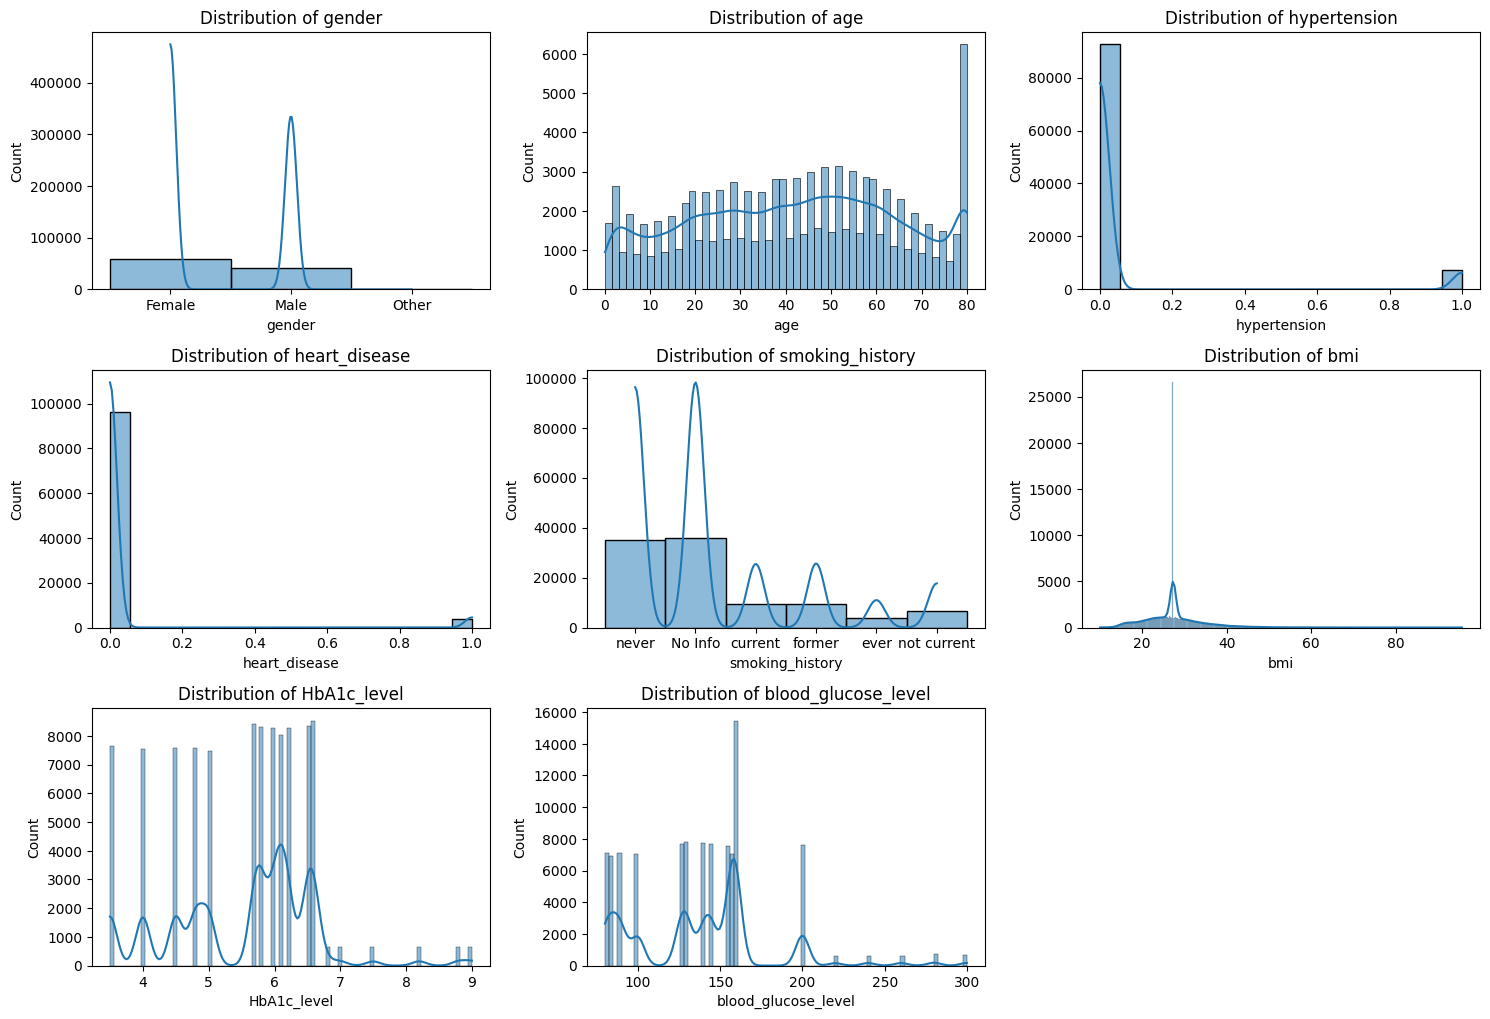

In [ ]:
# Examine only attribute columns
# Using histograms

df2 = df.drop(['diabetes'], axis=1)
columns = df2.columns
plt.figure(figsize=(15, 20)) # Creates a figure to hold all plots

for i, column in enumerate(columns, 1):
    plt.subplot(6, 3, i)
    sns.histplot(df2[column], kde=True)
    plt.title(f'Distribution of {column}')

plt.tight_layout()  # Adjust layout so plots don't overlap
plt.show()

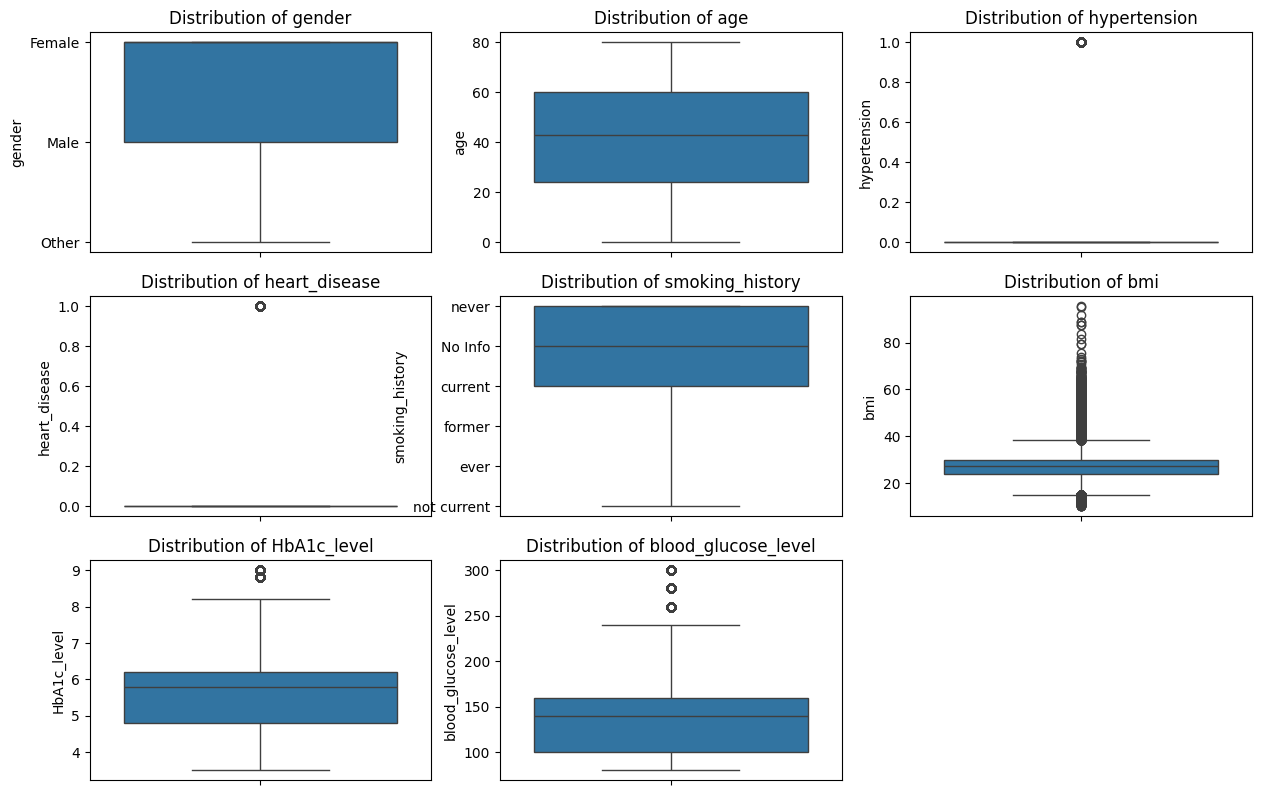

In [ ]:
# Using box plots

plt.figure(figsize=(15, 20)) # Creates a figure to hold all plots

for i, column in enumerate(columns, 1):
    plt.subplot(6, 3, i)
    sns.boxplot(df2[column])
    plt.title(f'Distribution of {column}')

From the histograms and boxplots, we can see the distribution of each feature.

- **Gender**: There seems to be a relatively equal number of males and females in this dataset. The distribution seems balanced.
- **Age**: The distribution seems to center around a median of 40, with a large amount of samples in their 80s, making the distribution slightly skewed to the left. Since this is a diabetes prediction dataset, it may make sense that more people are older as it could reflect the population targeted for diabetes prediction. So, it is not entirely clear where they count as outliers or not.
- **Hypertension**: There are only two types of data since 0 represents no hypertension and 1 represents having hypertension. A majority of the people in the dataset do not have hypertension, causing a big class imbalance, which could influence model performance. A strategy like resampling or using class weights could help improve the model's ability to generalize.
- **Heart disease**: Similar to hypertension, the majority do not have heart disease, causing class imbalance.
- **Smoking history**: This data centers around "never" and "No info". There is class imbalance as the other categories are significantly less. The "No info" also indicates missing data, which could pose a problem for data analysis. We can handle this missing data by imputing values or treating it as a separate category in some cases.
- **BMI**: The median BMI is around 30 and most of the data is centered around 10-40 (right-skew). There are a very small amount of data outside of this range- with high BMI, making them outliers.
- **HbA1c level**: The median of HbA1c levels is around 6, with most of the data clustering between 5 and 6.5. There are some outliers near 8 and 9.
- **Blood glucose level**: The median lies around 150, with a spike near 155. Most of the values are clustered at 100-200. There are some outliers at the right extremity of 250-300.

For features like blood glucose and BMI, normalization or transformations (e.g., log transformation) might be needed before modeling. For significant outliers, it may be beneficial to use methods like capping or removing extreme values to improve the model.

For skewed attributes, normalization, scaling, or transformations may help improve the model.

From the insights gained with the box plot, we can determine that **outliers** can be found in:

- Hypertension
- Heart disease
- Distribution of BMI
- Distribution of HbA1c level

### 3. **Target Variable Distribution**:

- Analyze the distribution of the target variable to identify class imbalances. Use bar plots to visualize the class frequencies.

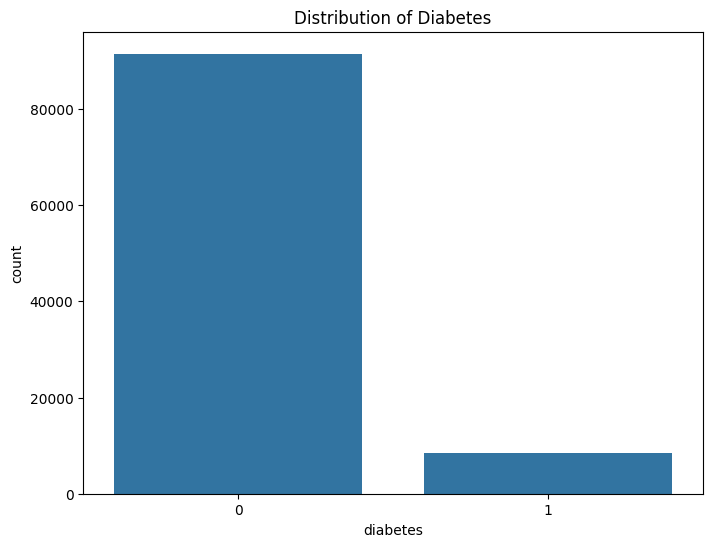

In [ ]:
# Bar plot to visualize class frequencies
plt.figure(figsize=(8, 6))
sns.countplot(x='diabetes', data=df)
plt.title('Distribution of Diabetes')
plt.show()

According to the bar plot for diabetes, the class is **highly imbalanced** with most of the samples not having diabetes (represented as 0) and a very small minority having diabetes (represented as 1).

This is very common in medical datasets as few people will have a certain disease compared to the whole population.

### 4. **Data Splitting**:

- Split the dataset into training (80%) and test (20%) sets using the holdout method.

- Ensure that this split occurs before any preprocessing to avoid data leakage.

In [ ]:
# Features
X = df.drop(['diabetes'], axis=1)

# Target class
y = df['diabetes']

# Split and reserve 20% data for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

## Data Pre-Processing



### 5. **Categorical Variable Encoding**:

**Gender**, **Smoking_history**, **Heart_disease**, and **Hypertension** are categorical attributes.
- **Gender** is a Nominal attribute as it does not have a true zero and no order
- **Heart disease** and **hypertension** are nominal attributes are they are binary and represent the presence or absence of something
- **Smoking history** is an ordinal attribute and can be given an order based on a timeline

We will use **one-hot encoding** to encode the **gender**, **heart disease** and **hypertension** attributes as they have a low cardinality and no order, making one-hot encoding ideal.

We will use **ordinal encoding** to encode the **smoking history** attribute as it has a high cardinality and has an order, which will make one-hot encoding inadequate.

### One-hot encoding

In [ ]:
# Values of gender
print(X_train['gender'].unique())

# Values of smoking history
print(X_train['smoking_history'].unique())

# Values of heart disease
print(X_train['heart_disease'].unique())

# Values of hypertension
print(X_train['hypertension'].unique())

['Female' 'Male' 'Other']
['No Info' 'never' 'former' 'current' 'not current' 'ever']
[0 1]
[0 1]


In [ ]:
# Encode training data

# One hot encoding gender
df_encode= pd.get_dummies(X_train, columns=['gender'], prefix='gender')

# One hot encoding heart disease
df_encode= pd.get_dummies(df_encode, columns=['heart_disease'], prefix='heart_disease')

# One hot encoding hypertension
df_encode= pd.get_dummies(df_encode, columns=['hypertension'], prefix='hypertension')

print(df_encode.head())

         age smoking_history    bmi  HbA1c_level  blood_glucose_level  \
91526  37.00         No Info  26.02          6.1                  160   
19416   3.00         No Info  20.55          6.5                  100   
99079  16.00         No Info  14.97          6.5                  100   
45086   1.32         No Info  16.94          4.5                  159   
54659  65.00           never  31.91          6.6                  140   

       gender_Female  gender_Male  gender_Other  heart_disease_0  \
91526           True        False         False             True   
19416          False         True         False             True   
99079           True        False         False             True   
45086           True        False         False             True   
54659          False         True         False            False   

       heart_disease_1  hypertension_0  hypertension_1  
91526            False            True           False  
19416            False            True

In [ ]:
# encode the test data as well

df_encoded_test = pd.get_dummies(X_test, columns=['gender'], prefix='gender')
df_encoded_test = pd.get_dummies(df_encoded_test, columns=['heart_disease'], prefix='heart_disease')
df_encoded_test = pd.get_dummies(df_encoded_test, columns=['hypertension'], prefix='hypertension')
print(df_encoded_test.head())

        age smoking_history    bmi  HbA1c_level  blood_glucose_level  \
33909  67.0     not current  29.15          6.2                  100   
92307   4.0           never  27.32          6.5                  140   
89107  40.0           never  29.47          6.2                  130   
9538   53.0           never  27.32          6.1                  155   
31008  65.0         No Info  49.71          5.8                  130   

       gender_Female  gender_Male  gender_Other  heart_disease_0  \
33909          False         True         False             True   
92307           True        False         False             True   
89107           True        False         False             True   
9538           False         True         False             True   
31008          False         True         False             True   

       heart_disease_1  hypertension_0  hypertension_1  
33909            False            True           False  
92307            False            True      

### Ordinal encoding

In [ ]:
# Values of smoking history
print(X_train['smoking_history'].unique())

['No Info' 'never' 'former' 'current' 'not current' 'ever']


In [ ]:
# Encode training data for smoking history

values = X_train['smoking_history'].values.reshape(-1, 1)
encoder = OrdinalEncoder(categories=[['No Info', 'not current', 'former', 'ever', 'never', 'current']])
encoder.fit(values)
values_encoded = encoder.transform(values)
print(values_encoded)

# add to data frame

values = values_encoded.reshape(-1) #reflatten to original format
df_encode['smoking_history'] = values
print(df_encode.head())

[[0.]
 [0.]
 [0.]
 ...
 [4.]
 [4.]
 [4.]]
         age  smoking_history    bmi  HbA1c_level  blood_glucose_level  \
91526  37.00              0.0  26.02          6.1                  160   
19416   3.00              0.0  20.55          6.5                  100   
99079  16.00              0.0  14.97          6.5                  100   
45086   1.32              0.0  16.94          4.5                  159   
54659  65.00              4.0  31.91          6.6                  140   

       gender_Female  gender_Male  gender_Other  heart_disease_0  \
91526           True        False         False             True   
19416          False         True         False             True   
99079           True        False         False             True   
45086           True        False         False             True   
54659          False         True         False            False   

       heart_disease_1  hypertension_0  hypertension_1  
91526            False            True         

In [ ]:
# Encode test data as well

values2 = X_test['smoking_history'].values.reshape(-1, 1)
values_encoded = encoder.transform(values2) # do not fit
df_encoded_test['smoking_history'] = values_encoded.reshape(-1) #reflatten to original format
print(df_encoded_test.head())

        age  smoking_history    bmi  HbA1c_level  blood_glucose_level  \
33909  67.0              1.0  29.15          6.2                  100   
92307   4.0              4.0  27.32          6.5                  140   
89107  40.0              4.0  29.47          6.2                  130   
9538   53.0              4.0  27.32          6.1                  155   
31008  65.0              0.0  49.71          5.8                  130   

       gender_Female  gender_Male  gender_Other  heart_disease_0  \
33909          False         True         False             True   
92307           True        False         False             True   
89107           True        False         False             True   
9538           False         True         False             True   
31008          False         True         False             True   

       heart_disease_1  hypertension_0  hypertension_1  
33909            False            True           False  
92307            False            True

### 6. **Normalization/Standardization of Numerical Features**:

- Normalize or standardize numerical features if necessary. Describe the technique used (e.g., Min-Max scaling, StandardScaler) and explain why it is suitable for this dataset.

- Ensure that this technique is applied only to the training data, with the same transformation subsequently applied to the test data without fitting on it.


**Age, bmi, HbA1c_level, blood_glucose_level** are numerical attributes.

These numerical attributes are ratio-scaled as they all have a true zero.

We will use **standardization** on the **BMI, HbA1c_level and blood_glucose_level** as they have outliers. The StandardScaler function will be used to transform these features to have a mean of 0 and a standard deviation of 1.

We will use **normalization** on **age** attribute. MinMaxScaler will be used for normalization to fix ages to a range of [-1,1].

### Standardization

            age  smoking_history       bmi  HbA1c_level  blood_glucose_level  \
91526  0.461962              0.0 -0.198072     0.532067             0.537878   
19416  0.036537              0.0 -1.022315     0.906184            -0.931941   
99079  0.199199              0.0 -1.863133     0.906184            -0.931941   
45086  0.015516              0.0 -1.566285    -0.964402             0.513381   
54659  0.812312              4.0  0.689458     0.999714             0.047938   

       gender_Female  gender_Male  gender_Other  heart_disease_0  \
91526           True        False         False             True   
19416          False         True         False             True   
99079           True        False         False             True   
45086           True        False         False             True   
54659          False         True         False            False   

       heart_disease_1  hypertension_0  hypertension_1  
91526            False            True           Fals

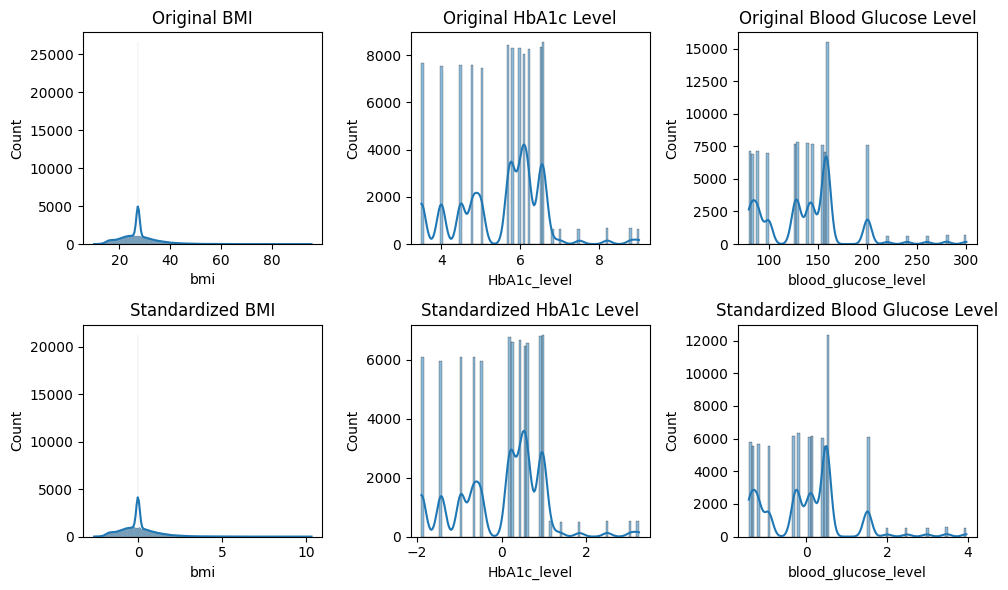

In [ ]:
# Standardize the relevant columns (training data)
scaler = StandardScaler()
df_encode[['bmi', 'HbA1c_level', 'blood_glucose_level']] = scaler.fit_transform(df_encode[['bmi', 'HbA1c_level', 'blood_glucose_level']])
print(df_encode.head())

# Visualize data before and after standardization for comparison
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

# =========================================================================== #

# Plot the original 'bmi' feature
sns.histplot(df['bmi'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Original BMI')

# Plot the standardized 'bmi' feature
sns.histplot(df_encode['bmi'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Standardized BMI')

# =========================================================================== #

# Plot the original 'HbA1c_level' feature
sns.histplot(df['HbA1c_level'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Original HbA1c Level')

# Plot the standardized 'HbA1c_level' feature
sns.histplot(df_encode['HbA1c_level'], kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Standardized HbA1c Level')

# =========================================================================== #

# Plot the original 'blood_glucose_level' feature
sns.histplot(df['blood_glucose_level'], kde=True, ax=axes[0, 2])
axes[0, 2].set_title('Original Blood Glucose Level')

# Plot the standardized 'blood_glucose_level' feature
sns.histplot(df_encode['blood_glucose_level'], kde=True, ax=axes[1, 2])
axes[1, 2].set_title('Standardized Blood Glucose Level')

plt.tight_layout()
plt.show()

In [ ]:
# Standardization on test data
df_encoded_test[['bmi', 'HbA1c_level', 'blood_glucose_level']] = scaler.transform(df_encoded_test[['bmi', 'HbA1c_level', 'blood_glucose_level']])
print(df_encoded_test.head())

            age  smoking_history       bmi  HbA1c_level  blood_glucose_level  \
33909  0.837337              1.0  0.273570     0.625596            -0.931941   
92307  0.049049              4.0 -0.002182     0.906184             0.047938   
89107  0.499499              4.0  0.321789     0.625596            -0.197031   
9538   0.662162              4.0 -0.002182     0.532067             0.415393   
31008  0.812312              0.0  3.371638     0.251479            -0.197031   

       gender_Female  gender_Male  gender_Other  heart_disease_0  \
33909          False         True         False             True   
92307           True        False         False             True   
89107           True        False         False             True   
9538           False         True         False             True   
31008          False         True         False             True   

       heart_disease_1  hypertension_0  hypertension_1  
33909            False            True           Fals

### Normalization

            age  smoking_history       bmi  HbA1c_level  blood_glucose_level  \
91526  0.461962              0.0 -0.198072     0.532067             0.537878   
19416  0.036537              0.0 -1.022315     0.906184            -0.931941   
99079  0.199199              0.0 -1.863133     0.906184            -0.931941   
45086  0.015516              0.0 -1.566285    -0.964402             0.513381   
54659  0.812312              4.0  0.689458     0.999714             0.047938   

       gender_Female  gender_Male  gender_Other  heart_disease_0  \
91526           True        False         False             True   
19416          False         True         False             True   
99079           True        False         False             True   
45086           True        False         False             True   
54659          False         True         False            False   

       heart_disease_1  hypertension_0  hypertension_1  
91526            False            True           Fals

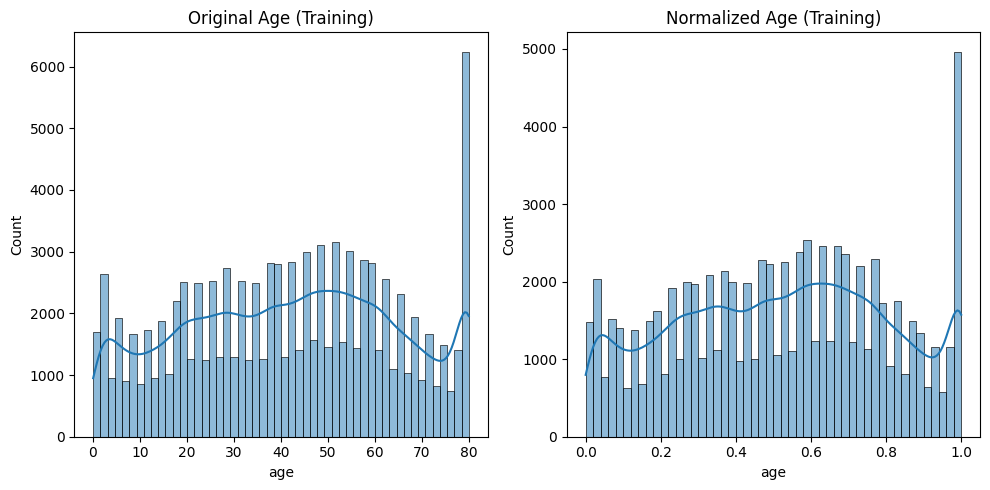

In [ ]:
# Normalization on training data

scaler = MinMaxScaler()
df_encode[['age']] = scaler.fit_transform(df_encode[['age']])
print(df_encode.head())

# Visualize data before and after normalization for comparison on training data
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # Adjusted the figure size

# Plot the original 'age' feature for training data
sns.histplot(df['age'], kde=True, ax=axes[0])
axes[0].set_title('Original Age (Training)')

# Plot the normalized 'age' feature for training data
sns.histplot(df_encode['age'], kde=True, ax=axes[1])
axes[1].set_title('Normalized Age (Training)')

plt.tight_layout()
plt.show()

In [ ]:
# Normalization on test data
df_encoded_test[['age']] = scaler.transform(df_encoded_test[['age']])
print(df_encoded_test.head())

            age  smoking_history       bmi  HbA1c_level  blood_glucose_level  \
33909  0.837337              1.0  0.273570     0.625596            -0.931941   
92307  0.049049              4.0 -0.002182     0.906184             0.047938   
89107  0.499499              4.0  0.321789     0.625596            -0.197031   
9538   0.662162              4.0 -0.002182     0.532067             0.415393   
31008  0.812312              0.0  3.371638     0.251479            -0.197031   

       gender_Female  gender_Male  gender_Other  heart_disease_0  \
33909          False         True         False             True   
92307           True        False         False             True   
89107           True        False         False             True   
9538           False         True         False             True   
31008          False         True         False             True   

       heart_disease_1  hypertension_0  hypertension_1  
33909            False            True           Fals

In [ ]:
# Replace the X training and X testing data with encoded data

X_train = df_encode
X_test = df_encoded_test

## Model Development & Evaluation



### 7. **Model Development**:

- Implement the machine learning models covered in class: Decision Trees, K-Nearest Neighbors (KNN), and Logistic Regression. Use the default parameters of scikit-learn as a baseline for training each model.

### Decision Tree

In [ ]:
# Train the model
clf = tree.DecisionTreeClassifier()

clf.fit(X_train, y_train)

DecisionTreeClassifier()

### KNN

In [ ]:
# KNN with 3 neighbors
neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

### Logistic Regression

In [ ]:
# Use Logistic Regression classifier

lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)

LogisticRegression()

### 8. **Model Evaluation**:

- Use cross-validation to evaluate each model, justifying your choice of the number of folds.

- Assess the models using metrics such as precision, recall, and F1-score.

**Cross-validation**
For this dataset, we will be using **10-fold** cross validation.
The diabetes dataset is relatively large with 100,000 rows of data in total.

With 10 folds, each training sample will have 10,000 rows, which is a good balance between having efficient performance and good values to compute the metrics of the model.

**Compute the mean accuracy and standard deviation of each model**

In [ ]:
# Perform cross validation for each model

decision_scores = cross_val_score(clf, X_train, y_train, cv=10)
knn_scores = cross_val_score(neigh, X_train, y_train, cv=10)
lr_scores = cross_val_score(lr_clf, X_train, y_train, cv=10)

In [ ]:
# Print decision tree score

print("Decision Tree Metrics:")
print("Scores:", decision_scores)
print("Mean:", f"{decision_scores.mean():.2f}")
print("Standard Deviation:", f"{decision_scores.std():.2f}")

Decision Tree Metrics:
Scores: [0.949875 0.951375 0.9555   0.953125 0.951875 0.949375 0.954    0.948875
 0.95125  0.95125 ]
Mean: 0.95
Standard Deviation: 0.00


In [ ]:
# Print KNN scores

print("KNN Metrics:")
print("Scores:", knn_scores)
print("Mean:", f"{knn_scores.mean():.2f}")
print("Standard Deviation:", f"{knn_scores.std():.2f}")

KNN Metrics:
Scores: [0.959875 0.96175  0.96225  0.962125 0.96025  0.957125 0.960625 0.9605
 0.96075  0.95925 ]
Mean: 0.96
Standard Deviation: 0.00


In [ ]:
# Print Logistic regression scores

print("Logistic regression Metrics:")
print("Scores:", lr_scores)
print("Mean:", f"{lr_scores.mean():.2f}")
print("Standard Deviation:", f"{lr_scores.std():.2f}")

Logistic regression Metrics:
Scores: [0.9575   0.960875 0.9635   0.964    0.95975  0.956875 0.95675  0.961625
 0.961    0.959125]
Mean: 0.96
Standard Deviation: 0.00


According to the metrics, KNN and Logistic regression have the highest mean accuracy of 96% compared to Decision trees with a mean of 95%. This makes KNN and Logistic regression the better models for prediction.

**Compute the F1, Precision and Recall for each model.**

In [ ]:
# Decision tree

# Use cross_val_predict to obtain predicted values
y_pred = cross_val_predict(clf, X_train, y_train, cv=10)

# Calculate precision, recall, and F1-score
precision = precision_score(y_train, y_pred)
recall = recall_score(y_train, y_pred)
f1 = f1_score(y_train, y_pred)

print("Decision Tree Metrics:")
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Decision Tree Metrics:
Precision: 0.7044979807826208
Recall: 0.7417888563049854
F1-score: 0.7226626669523606


In [ ]:
# KNN

# Use cross_val_predict to obtain predicted values
y_pred = cross_val_predict(neigh, X_train, y_train, cv=10)

# Calculate precision, recall, and F1-score
precision = precision_score(y_train, y_pred)
recall = recall_score(y_train, y_pred)
f1 = f1_score(y_train, y_pred)

print("KNN Metrics:")
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

KNN Metrics:
Precision: 0.8487218618847768
Recall: 0.6523460410557185
F1-score: 0.737688608854253


In [ ]:
# Logistic Regression

# Use cross_val_predict to obtain predicted values
y_pred = cross_val_predict(lr_clf, X_train, y_train, cv=10)

# Calculate precision, recall, and F1-score
precision = precision_score(y_train, y_pred)
recall = recall_score(y_train, y_pred)
f1 = f1_score(y_train, y_pred)

print("Logistic Regression Metrics:")
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Logistic Regression Metrics:
Precision: 0.8688491256608377
Recall: 0.6265395894428153
F1-score: 0.7280627023342988


According to the precision, recall and F1 metrics, we can conclude that Logistic regression has the highest precision, Decision tree has the highest Recall and KNN has the highest F1-Score.

## Hyperparameter Optimization



### 9. **Exploration and Performance Evaluation:**

  - Investigate the impact of varying hyperparameter values on the performance of each model.

  - Focus on the following relevant hyperparameters for each model:

      - [DecisionTreeClassifier](https://scikit-learn.org/dev/modules/generated/sklearn.tree.DecisionTreeClassifier.html): `criterion` and `max_depth`.

      - [LogisticRegression](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html): `penalty`, `max_iter`, and `tol`.

      - [KNeighborsClassifier](https://scikit-learn.org/dev/modules/generated/sklearn.neighbors.KNeighborsClassifier.html): `n_neighbors` and `weights`.

  - Employ a grid search strategy or utilize scikit-learn's built-in methods to thoroughly evaluate all combinations of hyperparameter values. Cross-validation should be used to assess each combination.

  - Quantify the performance of each hyperparameter configuration using precision, recall, and F1-score as metrics.

  - Display the results in a tabular or graphical format (e.g., line charts, bar charts) to effectively demonstrate the influence of hyperparameter variations on model performance.

  - Specify the default values for each hyperparameter tested.

  - Analyze the findings and offer insights into which hyperparameter configurations achieved optimal performance for each model.

**Decision Tree**

In [ ]:
# Decision Tree

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': range(1,10)
}

grid_search_f1 = GridSearchCV(clf, param_grid, cv=10, scoring='f1')
grid_search_f1.fit(X_train, y_train)

grid_search_precision = GridSearchCV(clf, param_grid, cv=10, scoring='precision')
grid_search_precision.fit(X_train, y_train)

grid_search_recall = GridSearchCV(clf, param_grid, cv=10, scoring='recall')
grid_search_recall.fit(X_train, y_train)

print("Best params:", grid_search_recall.best_params_)

print("Best precision:", grid_search_f1.best_score_) #best precision
print("Best recall:", grid_search_recall.best_score_) #best recall
print("Best F1:", grid_search_f1.best_score_) #best f1


Best params: {'criterion': 'gini', 'max_depth': 9}
Best precision: 0.8062663788673868
Best recall: 0.6819648093841642
Best F1: 0.8062663788673868


In [ ]:
# Visualize how metrics vary with the combinations of params

# Add to dataframe all metrics for all parameter combinations
df_f1 = pd.DataFrame(grid_search_f1.cv_results_)
df_precision = pd.DataFrame(grid_search_precision.cv_results_)
df_recall = pd.DataFrame(grid_search_recall.cv_results_)

# Build dataframe containing parameter combinations and the mean score for each metric
summary_df = pd.DataFrame({
    'params': df_f1['params'],
    'mean_test_f1': df_f1['mean_test_score'],
    'mean_test_precision': df_precision['mean_test_score'],
    'mean_test_recall': df_recall['mean_test_score']
})

print(summary_df)

                                      params  mean_test_f1  \
0      {'criterion': 'gini', 'max_depth': 1}      0.627583   
1      {'criterion': 'gini', 'max_depth': 2}      0.802540   
2      {'criterion': 'gini', 'max_depth': 3}      0.802540   
3      {'criterion': 'gini', 'max_depth': 4}      0.802540   
4      {'criterion': 'gini', 'max_depth': 5}      0.802540   
5      {'criterion': 'gini', 'max_depth': 6}      0.802540   
6      {'criterion': 'gini', 'max_depth': 7}      0.802540   
7      {'criterion': 'gini', 'max_depth': 8}      0.804686   
8      {'criterion': 'gini', 'max_depth': 9}      0.806266   
9   {'criterion': 'entropy', 'max_depth': 1}      0.627583   
10  {'criterion': 'entropy', 'max_depth': 2}      0.802540   
11  {'criterion': 'entropy', 'max_depth': 3}      0.802540   
12  {'criterion': 'entropy', 'max_depth': 4}      0.802540   
13  {'criterion': 'entropy', 'max_depth': 5}      0.802540   
14  {'criterion': 'entropy', 'max_depth': 6}      0.802540   
15  {'cr

The best parameters for decision tree are the criterion gini and a depth of 9.

These produce the highest mean precision, recall and f1.

**KNN**

In [ ]:
# Decision Tree

param_grid = {
    'n_neighbors': range(1, 15),
    'weights': ['uniform', 'distance']
}

grid_search_f1 = GridSearchCV(neigh, param_grid, cv=10, scoring='f1')
grid_search_f1.fit(X_train, y_train)

grid_search_precision = GridSearchCV(neigh, param_grid, cv=10, scoring='precision')
grid_search_precision.fit(X_train, y_train)

grid_search_recall = GridSearchCV(neigh, param_grid, cv=10, scoring='recall')
grid_search_recall.fit(X_train, y_train)

print("Best params:", grid_search_recall.best_params_)

print("Best precision:", grid_search_precision.best_score_) #best precision
print("Best recall:", grid_search_recall.best_score_) #best recall
print("Best F1:", grid_search_f1.best_score_) #best f1


Best params: {'n_neighbors': 1, 'weights': 'uniform'}
Best precision: 0.9748907894379659
Best recall: 0.6929618768328447
Best F1: 0.7405430985721403


In [ ]:
# Visualize how metrics vary with the combinations of params
# KNN


**Logistic Regression**

In [ ]:
# Logistic Regression



In [ ]:
# Visualize how metrics vary with the combinations of params
# logistic

todo
blabla

## Analysis of Results



### 10. **Model Comparison**:

- Compare the results obtained from each model.

- Discuss observed differences in model performance, providing potential explanations. Consider aspects such as model complexity, data imbalance, overfitting, and the impact of parameter tuning on overall results.

- Provide recommendations on which model(s) to choose for this task and justify your choices based on the analysis results.

- Train the recommended model(s) using the optimal parameter values identified from the parameter optimization step. Subsequently, apply the trained model to the test data. Document your observations comprehensively. Specifically, evaluate whether the results derived from cross-validation are consistent with those obtained from the test set.

In [ ]:
# Code cell
# urg

## 2. Documentation of Exploratory Analysis

The report should comprehensively document the entire process followed during this assignment. The Jupyter Notebook must include the following:

- Your name(s), student number(s), and a report title.
- Explain how the tasks have been split between the members. How did you make sure that both students achieve the learning outcomes?
- A section for each step of the exploratory analysis, containing the relevant Python code and explanations or results.
  - For sections requiring Python code, include the code in a cell.
  - For sections requiring explanations or results, include these in a separate cell or in combination with code cells.
- Ensure logical separation of code into different cells. For example, the definition of a function should be in one cell and its execution in another. Avoid placing too much code in a single cell to maintain clarity and readability.
- The notebook you submit must include the results of the execution, complete with graphics, ensuring that the teaching assistant can grade the notebook without needing to execute the code.



# Resources

https://turcotte.xyz/teaching/csi-4106/lectures/08/slides.html#/standardization-or-normalization

https://colab.research.google.com/drive/1_I0kgnkjU-N9uQZhSF6QbNOjsMvmg8I7?usp=sharing

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier

https://turcotte.xyz/teaching/csi-4106/lectures/07/slides.html#/k-fold-cross-validation